<div style="text-align: center; margin-top: 20px;">
  <img 
    src="https://raw.githubusercontent.com/salavii/llm-from-scratch/main/images/pre.png"
    style="width: 750px; border-radius: 10px; display: block; margin-left: auto; margin-right: auto;"
  >


## Using GPT to generate text
Let’s set up the LLM and briefly recap the text generation process we implemented in
chapter 4. We begin by initializing the GPT model that we will later evaluate and train
using the GPTModel class and GPT_CONFIG_124M dictionary (see chapter 4):

In [4]:
import torch
from Attention import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,   
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12, 
    "drop_rate": 0.1,      
    "qkv_bias": False
                 }
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

## Config change for training

- Compared to the previous chapter, the only change in `GPT_CONFIG_124M` is:
    - `context_length` reduced to 256 tokens

- This lowers training compute and makes training feasible on a standard laptop.

Longer contexts increase attention cost significantly, so using a shorter context is a practical training setup. After training, the context setting will be updated back to 1024 tokens, and pretrained weights will be loaded for a **1024-token** GPT-2 style model

## Three-Step Text Generation with GPT

### Step 1: Text → Token IDs

- The tokenizer encodes raw text into token IDs.

The model does not operate on text directly; all inputs must be numerical.

### Step 2: Token IDs → Logits

- The model processes token IDs and outputs logits.
- Each logit vector represents a probability distribution over the vocabulary.

### Step 3: Logits / Token IDs → Text

- Logits are converted into token IDs.
- The tokenizer decodes token IDs back into human-readable text

In [25]:
import tiktoken
from Attention import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())


In [27]:
# Example usage
start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you know," was one of the axioms he


### Why we need numerical evaluation

The model generates incoherent text because it is untrained.

To define “coherent” or “high-quality” text during training, we need a numerical evaluation method.

A numeric metric lets us track progress objectively instead of relying on subjective inspection

In [5]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
               [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                [1107, 588, 11311]])  #  " really like chocolate"]

In [6]:
with torch.no_grad():    
    logits = model(inputs)
probas = torch.softmax(logits, dim=-1)    
print(probas.shape)

torch.Size([2, 3, 50257])


In [7]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


Finally, step 5 converts the token IDs back into text:

In [8]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1:"
      f"{token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1: Armed heNetflix


The model produces random text that is different from the target text because it has
not been trained yet. We now want to evaluate the performance of the model’s gen
erated text numerically via a loss (figure 5.5). Not only is this useful for measuring
the quality of the generated text, but it’s also a building block for implementing the
training function, which we will use to update the model’s weight to improve the
generated text.

### Evaluating distance from target tokens

- Text evaluation measures how far the model’s predictions are from the targets.
- This information is later used by the training function to update model weights.

The goal of training is to increase the **softmax probability assigned to the correct target token IDs**. Higher probability at the correct positions indicates better model performance.

Softmax probabilities are directly used in the evaluation metric.

Higher probability for correct tokens → lower loss → better generation quality

In [9]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([7.4541e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


# Backpropagation
How do we maximize the softmax probability values corresponding to the target
tokens? The big picture is that we update the model weights so that the model outputs
higher values for the respective token IDs we want to generate. The weight update is
done via a process called backpropagation, a standard technique for training deep
neural networks (see sections A.3 to A.7 in appendix A for more details about back
propagation and model training).
Backpropagation requires a loss function, which calculates the difference between
the model’s predicted output (here, the probabilities corresponding to the target
token IDs) and the actual desired output. This loss function measures how far off the
model’s predictions are from the target values

In [10]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)


tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


<div style="text-align: center; margin-top: 20px;">
  <img 
    src="https://raw.githubusercontent.com/salavii/llm-from-scratch/main/images/loss.png"
    style="width: 750px; border-radius: 10px; display: block; margin-left: auto; margin-right: auto;"
  >


In [11]:
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)


tensor(-10.7940)


#### Averaging log probabilities
- Log probabilities are easier to optimize than raw probabilities.
- After computing the log probability for each correct target token, we combine them into a single score

In [12]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


#### Negative average log probability and cross-entropy
- Training aims to maximize the average log probability of correct target tokens.
- In practice, deep learning minimizes a loss, so we use the negative average log probability instead

Before we apply the cross_entropy function, let’s briefly recall the shape of the logits
and target tensors:

In [13]:
print("Logits shape:", logits.shape)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


#### PyTorch’s cross_entropy expects:

- logits of shape (N, vocab_size)
- targets of shape (N,)

Therefore, we flatten (reshape) both tensors by combining the batch and token dimensions. Each token prediction is treated as an independent classification example

In [14]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


## Cross-entropy from logits and targets

- targets are the correct token IDs the model should predict.
- logits are the model’s raw (unnormalized) scores before softmax.

Previously, we computed loss manually by:

- applying softmax
- selecting target-token probabilities
- taking log
- averaging
- negating the result

PyTorch’s cross_entropy performs these steps internally

In [15]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


## Perplexity (Intuition)
- Perplexity is commonly used alongside cross-entropy loss in language modeling.
- It provides an interpretable measure of model uncertainty.

Perplexity is computed as <br/>
**perplexity = exp(loss)**

- Lower perplexity → better predictions
- Higher perplexity → more uncertainty

Perplexity can be interpreted as the effective number of tokens the model is unsure about at each prediction step.

In this example:

`perplexity ≈ 48,725`

This means the model is almost equally unsure among most tokens in the vocabulary, which is expected for an untrained model

# Training and validation losses

- Before training the LLM, we prepare:
    - a training dataset
    - a validation dataset

During training, we compute cross-entropy loss on both sets.
- Training loss measures how well the model fits the training data.
- Validation loss measures how well the model generalizes to unseen data

In [16]:
file_path = "the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

In [17]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


#### Data splitting and input length

- For simplicity and efficiency, we train the model using fixed-length chunks.
- In practice, training with variable-length inputs can improve generalization.

We split the dataset as follows:

- 90% for training
- 10% for validation (model evaluation during training)

This setup keeps the training pipeline simple while still enabling proper performance monitoring

In [18]:
train_ratio = 0.9
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [19]:
from Attention import CreateDataLoader_V1
torch.manual_seed(123)

train_loader = CreateDataLoader_V1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = CreateDataLoader_V1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [20]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)
print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [21]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)        
    target_batch = target_batch.to(device)      
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
           logits.flatten(0, 1), 
           target_batch.flatten()
    )
    return loss

We can now use this calc_loss_batch utility function, which computes the loss for a
single batch, to implement the following calc_loss_loader function that computes
the loss over all the batches sampled by a given data loader.

In [22]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.0

    # if the data loader is empty, return NaN
    if len(data_loader) == 0:
        return NaN

    
    # If num_batches is not specified, use all batches
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))


    # Iterate over the dataloader
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break

        loss = calc_loss_batch(
            input_batch, target_batch, model, device
        )

        total_loss += loss.item()

        return total_loss / num_batches

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)  
with torch.no_grad():                                       
    train_loss = calc_loss_loader(train_loader, model, device)   
    val_loss = calc_loss_loader(val_loader, model, device)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 1.2197308010525174
Validation loss: 10.981107711791992


### Interpreting loss before training

- High loss values are expected because the model is untrained.
- If the model perfectly predicts the next token, the loss approaches 0.
- Now that we can measure text quality via loss, we proceed to train the LLM.
- Training aims to reduce both training and validation loss, improving text generation quality

# Training an LLM


In [24]:
def train_model_simple(
    model, train_loader, val_loader, 
    optimizer, device, num_epochs, 
    eval_freq, eval_iter, start_context, tokenizer):

    # Track metrics over time
    train_losses, val_losses, track_tokens_seen = [], [], []
    token_seen, global_step = 0, -1

    # Main training loop: epoch -> batches
    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()

            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )

            loss.backward()
            optimizer.step()

            token_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )

                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(token_seen)

                print(
                    f"Ep {epoch+1} (Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, "
                    f"Val loss {val_loss:.3f}"
                )

        # Optional: qualitative check (sample generation)
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen 

In [25]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()  # switch to evaluation mode

    with torch.no_grad():  # disable gradient tracking
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )

    model.train()  # switch back to training mode
    return train_loss, val_loss


In [26]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()

    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)

    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model,
            idx=encoded,
            max_new_tokens=50,
            context_size=context_size
        )

    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))

    model.train()


## AdamW 
Adam optimizers are a popular choice for training deep neural networks. However, in
our training loop, we opt for the AdamW optimizer. AdamW is a variant of Adam that
improves the weight decay approach, which aims to minimize model complexity and
prevent overfitting by penalizing larger weights. This adjustment allows AdamW to
achieve more effective regularization and better generalization; thus, AdamW is fre
quently used in the training of LLMs

In [60]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
     model.parameters(),          
    lr=0.0004, weight_decay=0.1
)
num_epochs = 10

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 1.979, Val loss 9.933
Ep 1 (Step 000005): Train loss 1.583, Val loss 8.339
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 1.369, Val loss 7.048
Ep 2 (Step 000015): Train loss 1.199, Val loss 6.616
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and,
Ep 3 (Step 000020): Train loss 1.132, Val loss 6.600
Ep 3 (Step 000025): Train loss 1.073, Val loss 6.348
Every effort moves you, and I had been.                                            
Ep 4 (Step 000030): Train loss 0.802, Val loss 6.278
Ep 4 (Step 000035): Train loss 0.510, Val loss 6.226
Every effort moves you know the                          "I he had the donkey and I had the and I had the donkey and down the room, I had
Ep 5 (Step 000040): Train loss 0.767, Val loss 6.160
Every effort moves you know it was not that the picture--I had the fact by the last

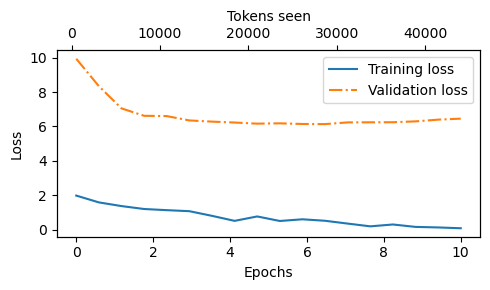

In [61]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()                  
    ax2.plot(tokens_seen, train_losses, alpha=0)    
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()
    
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## Overfitting Detection via Loss Curves

Both training and validation loss decrease during the first epoch.

After the second epoch, the losses start to diverge.

Training loss continues to decrease, while validation loss remains much higher.

This divergence is a strong indicator of overfitting.

Evidence of Memorization

The model generates text snippets that appear verbatim in the training data.

Example phrase: “quite insensible to the irony” found in The Verdict dataset.

This confirms that the model memorizes training samples instead of generalizing

# Decoding strategies to control randomness
- Decoding strategies determine how tokens are sampled from model output probabilities.
- They directly affect randomness, diversity, and originality of generated text.
- The baseline method uses greedy or simple sampling via generate_text_simple.

### Motivation for Improved Decoding
- Simple decoding often leads to repetitive or dull text.
- Advanced strategies introduce controlled randomness.

### Inference Setup
- The model is moved from GPU to CPU since inference for small models is lightweight.
- After training, model.eval() is called to disable stochastic layers such as dropout.
- Evaluation mode ensures deterministic and stable text generation

In [62]:
model.to("cpu")
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

Next, we plug the GPTModel instance (model) into the generate_text_simple func
tion, which uses the LLM to generate one token at a time:

In [63]:
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you know," was one of the axioms he laid down across the Sevres and silver of an exquisitely appointed lun


### Greedy Decoding Behavior

- At each generation step, the token with the highest probability is selected.
- This corresponds to applying argmax over the vocabulary.
- No randomness is involved in token selection.
- As a result, the model produces the same output for the same prompt every time.

### Limitation of Greedy Decoding

- Deterministic outputs reduce text diversity.
- Repeated generations from the same prompt are identical.
- Greedy decoding often leads to repetitive or dull text

# Temperature scaling
Temperature scaling introduces probabilistic sampling into next-token generation.

Greedy decoding selects the token with the highest probability using argmax.

Temperature replaces `argmax` with sampling from the model’s probability distribution.

Logits are divided by a temperature parameter before applying softmax.

Lower temperatures make the distribution sharper; higher temperatures increase diversity.

In [64]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 
inverse_vocab = {v: k for k, v in vocab.items()}

Next, assume the LLM is given the start context "every effort moves you" and gener
ates the following next-token logits:


In [65]:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

In [66]:
probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

forward


### From Greedy to Probabilistic Sampling

The highest logit (and highest softmax probability) occurs at index 3 (0-based indexing).

Therefore, greedy decoding selects the token "forward".

To introduce probabilistic token selection, replace argmax with torch.multinomial.

torch.multinomial samples token IDs according to the probability distribution, increasing output diversity

In [67]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


In [68]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)

    sample = [
        torch.multinomial(probas, num_samples=1).item()
        for i in range(1000)
    ]

    sampled_ids = torch.bincount(torch.tensor(sample))

    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


As we can see, the word forward is sampled most of the time (582 out of 1,000 times),
but other tokens such as closer, inches, and toward will also be sampled some of
the time. This means that if we replaced the argmax function with the multinomial
function inside the generate_and_print_sample function, the LLM would some
times generate texts such as every effort moves you toward, every effort moves
you inches, and every effort moves you closer instead of every effort moves you
forward.
 We can further control the distribution and selection process via a concept called
temperature scaling. Temperature scaling is just a fancy description for dividing the logits
by a number greater than 0:

In [69]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

**Temperatures greater than 1 result in more uniformly distributed token probabilities**

**temperatures smaller than 1 will result in more confident (sharper) distributions**

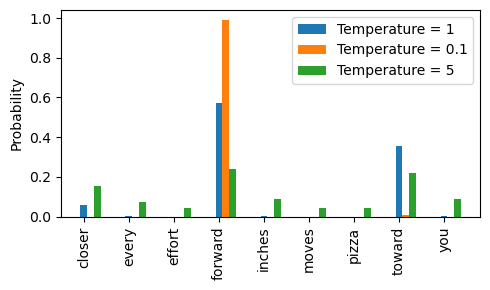

In [70]:
import matplotlib.pyplot as plt

temperatures = [1, 0.1, 5]                                    
scaled_probas = [softmax_with_temperature(next_token_logits, T)
        for T in temperatures]
x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], 
           bar_width, label=f'Temperature = {T}')
ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

## Motivation for Top-k Sampling

Probabilistic sampling with high temperature increases output diversity.

High diversity can lead to grammatically incorrect or nonsensical outputs.

Top-k sampling restricts token selection to the k most likely tokens.

All other tokens are excluded by masking their probability scores.

Combining temperature scaling with top-k sampling improves the balance between diversity and coherence

## Top-k Masking Mechanism

- Top-k sampling keeps only the k tokens with the highest logits.
- All non-top-k logits are replaced with negative infinity (−∞).
- After softmax, non-top-k tokens receive probability 0.
- The remaining top-k probabilities are renormalized to sum to 1.
- This masking technique is similar to the causal attention masking used earlier

In [71]:
top_k = 3 
top_logits, top_pos = torch.topk(next_token_logits, top_k) 
print("Top logits:", top_logits) 
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


Subsequently, we apply PyTorch’s where function to set the logit values of tokens that are
below the lowest logit value within our top-three selection to negative infinity (-inf): 

In [72]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],   
    input=torch.tensor(float('-inf')),    
    other=next_token_logits    
)
print(new_logits)


tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [73]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


### Combining Temperature and Top-k Sampling

After top-k masking, only the top-k tokens have non-zero probability.

We can apply temperature scaling to control how probability mass is distributed among the remaining tokens.

Then we sample the next token using torch.multinomial instead of argmax.

Next step: integrate these steps into the text generation loop by modifying generate_text_simple into a new generate function

In [23]:
import torch

def generate(model, idx, max_new_tokens, context_size,
             temperature=0.0, top_k=None, eos_id=None):
    """
    model: language model
    idx: (batch, seq_len) token ids
    max_new_tokens: how many tokens to generate
    context_size: max context window length
    temperature: 0.0 => greedy (argmax), >0 => sampling
    top_k: if set, restrict sampling to top-k tokens
    eos_id: if set, stop when EOS is generated (works best for batch=1)
    """
    for _ in range(max_new_tokens):
        # 1) Keep only the last context_size tokens
        idx_cond = idx[:, -context_size:]

        # 2) Forward pass (no gradients during inference)
        with torch.no_grad():
            logits = model(idx_cond)              # (batch, seq, vocab)

        # 3) Only last position logits are used for next-token selection
        logits = logits[:, -1, :]                 # (batch, vocab)

        # 4) Top-k masking (optional)
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k, dim=-1)   # (batch, top_k)
            min_val = top_logits[:, -1].unsqueeze(-1)           # (batch, 1)
            logits = torch.where(
                logits < min_val,
                torch.tensor(float('-inf'), device=logits.device),
                logits
            )

        # 5) Choose next token: sampling (temperature>0) or greedy (temperature==0)
        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch, 1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch, 1)

        # 6) Early stop on EOS (practical for batch=1; for batch>1 needs per-row handling)
        if eos_id is not None:
            if (idx_next == eos_id).all():
                break

        # 7) Append the new token to the sequence
        idx = torch.cat((idx, idx_next), dim=1)

    return idx


In [76]:
torch.manual_seed(123)
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you stand to work on surprise, a one of us had gone with random-


# Loading and saving model weights in PyTorch


Fortunately, saving a PyTorch model is relatively straightforward. The recommended
way is to save a model’s state_dict, a dictionary mapping each layer to its parameters,
using the torch.save function:

In [77]:
torch.save(model.state_dict(), "model.pth")


"model.pth" is the filename where the state_dict is saved. The .pth extension is a
convention for PyTorch files, though we could technically use any file extension. 
 Then, after saving the model weights via the state_dict, we can load the model
weights into a new GPTModel model instance:

In [78]:
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth", map_location=device))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

As discussed in chapter 4, dropout helps prevent the model from overfitting to the
training data by randomly “dropping out” of a layer’s neurons during training. How
ever, during inference, we don’t want to randomly drop out any of the information
the network has learned. Using model.eval() switches the model to evaluation mode
for inference, disabling the dropout layers of the model. 

If we plan to continue pre
training a model later—for example, using the train_model_simple function we
defined earlier in this chapter—saving the optimizer state is also recommended.
 Adaptive optimizers such as AdamW store additional parameters for each model
weight. AdamW uses historical data to adjust learning rates for each model parameter
dynamically. Without it, the optimizer resets, and the model may learn suboptimally
or even fail to converge properly, which means it will lose the ability to generate coher
ent text. Using torch.save, we can save both the model and optimizer state_dict
contents:

In [79]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    }, 
    "model_and_optimizer.pth"
)

Then we can restore the model and optimizer states by first loading the saved data via
torch.load and then using the load_state_dict method:

In [6]:
import torch
device = torch.device("cpu") 
from Attention import GPTModel
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,   
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12, 
    "drop_rate": 0.1,      
    "qkv_bias": False
}
    
checkpoint = torch.load("model_and_optimizer.pth", map_location=device)
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

# Loading pretrained weights from OpenAI

- Previously, a small GPT-2 model was trained on a limited dataset to learn core concepts.
- OpenAI publicly released pretrained GPT-2 weights, removing the need for costly large-scale training.
- These weights can be loaded into a custom GPTModel implementation for text generation.
- Model weights correspond to learned parameters stored in Linear and Embedding layers.
- The pretrained weights will later be reused for fine-tuning tasks such as text classification and instruction following.
- GPT-2 weights were originally saved using TensorFlow and require conversion for use in PyTorch.
- Additional tools like TensorFlow and tqdm are required to load and track the download process

In [9]:
import urllib.request

url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)

filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)


('gpt_download.py', <http.client.HTTPMessage at 0x2b93e110050>)

Next, after downloading this file to the local directory of your Python session, you
should briefly inspect the contents of this file to ensure that it was saved correctly and
contains valid Python code.
We can now import the download_and_load_gpt2 function from the gpt_download
.py file as follows, which will load the GPT-2 architecture settings (settings) and
weight parameters (params) into our Python session

In [10]:
from gpt_download import download_and_load_gpt2

settings, params = download_and_load_gpt2(
    model_size="124M",
    models_dir="gpt2"
)


checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 90.2kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:01<00:00, 549kiB/s] 
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 69.8kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [02:53<00:00, 2.86MiB/s]   
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 3.47MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:01<00:00, 254kiB/s]  
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 630kiB/s]  


Assuming the execution of the previous code has completed, let’s inspect the contents
of settings and params:

In [11]:
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [12]:
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


## GPT-2 Model Sizes and Architecture

- OpenAI provides pretrained weights for GPT-2 models of different sizes: 124M, 355M, 774M, and 1558M.
- All GPT-2 models share the same overall architecture.
- Model sizes differ in:
    - the number of repeated Transformer blocks
    - the embedding dimension
- The remaining code in this chapter is compatible with all GPT-2 sizes.
- After loading pretrained weights, they must be transferred from settings and params into a PyTorch GPTModel.
- A configuration dictionary is used to describe architectural differences between model sizes

<div style="text-align: center; margin-top: 20px;">
  <img 
    src="https://raw.githubusercontent.com/salavii/llm-from-scratch/main/images/G.png"
    style="width: 750px; border-radius: 10px; display: block; margin-left: auto; margin-right: auto;"
  >


In [13]:
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}


Suppose we are interested in loading the smallest model, "gpt2-small (124M)". We can
use the corresponding settings from the model_configs table to update our full-length
GPT_CONFIG_124M we defined and used earlier:

In [15]:
model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])

Careful readers may remember that we used a 256-token length earlier, but the origi
nal GPT-2 models from OpenAI were trained with a 1,024-token length, so we have to
update the NEW_CONFIG accordingly:


In [16]:
NEW_CONFIG.update({"context_length": 1024})

Also, OpenAI used bias vectors in the multi-head attention module’s linear layers to
implement the query, key, and value matrix computations. Bias vectors are not com
monly used in LLMs anymore as they don’t improve the modeling performance and
are thus unnecessary. However, since we are working with pretrained weights, we need
to match the settings for consistency and enable these bias vectors:


In [17]:
NEW_CONFIG.update({"qkv_bias": True})

In [18]:
gpt = GPTModel(NEW_CONFIG)
gpt.eval()


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

## ssigning Pretrained Weights to the Model

A newly initialized GPTModel starts with random weights.

To use OpenAI’s pretrained GPT-2 weights, these random weights must be overridden.

A small utility function is defined to safely assign pretrained weights.

The utility checks that the source and target tensors have matching shapes.

Matching weights are converted into trainable PyTorch parameters.

This prevents silent errors and ensures correct weight mapping

In [19]:
import torch

def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(
            f"Shape mismatch. Left: {left.shape}, Right: {right.shape}"
        )
    return torch.nn.Parameter(torch.tensor(right))


Next, we define a load_weights_into_gpt function that loads the weights from the
params dictionary into a GPTModel instance gpt

In [20]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    # 1) Embeddings
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params["wpe"])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params["wte"])

    # 2) Transformer blocks
    for b in range(len(params["blocks"])):

        # ---- Attention: QKV (GPT-2 stores them concatenated) ----
        q_w, k_w, v_w = np.split(
            params["blocks"][b]["attn"]["c_attn"]["w"], 3, axis=-1
        )
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T
        )
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T
        )
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T
        )

        q_b, k_b, v_b = np.split(
            params["blocks"][b]["attn"]["c_attn"]["b"], 3, axis=-1
        )
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b
        )
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b
        )
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b
        )

        # ---- Attention output projection ----
        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T
        )
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"]
        )

        # ---- Feedforward (MLP) ----
        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T
        )
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"]
        )

        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T
        )
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"]
        )

        # ---- LayerNorms inside block ----
        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"]
        )
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"]
        )

        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"]
        )
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"]
        )

    # 3) Final LayerNorm
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])

    # 4) Output head (weight tying with token embeddings)
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])


In the load_weights_into_gpt function, we carefully match the weights from
OpenAI’s implementation with our GPTModel implementation. To pick a specific
example, OpenAI stored the weight tensor for the output projection layer for the
first transformer block as params["blocks"][0]["attn"]["c_proj"]["w"]. In our
implementation, this weight tensor corresponds to gpt.trf_blocks[b].att.out_proj
.weight, where gpt is a GPTModel instance.
 Developing the load_weights_into_gpt function took a lot of guesswork since
OpenAI used a slightly different naming convention from ours. However, the assign
function would alert us if we try to match two tensors with different dimensions. Also,
if we made a mistake in this function, we would notice this, as the resulting GPT
model would be unable to produce coherent text.
 Let’s now try the load_weights_into_gpt out in practice and load the OpenAI
model weights into our GPTModel instance gpt:

In [21]:
load_weights_into_gpt(gpt, params)
gpt.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

If the model is loaded correctly, we can now use it to generate new text using our pre vious generate function:

In [30]:
torch.manual_seed(123)
token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you toward finding an ideal new way to practice something!

What makes us want to be on top of that?




We can be confident that we loaded the model weights correctly because the model can
produce coherent text. A tiny mistake in this process would cause the model to fail. In
the following chapters, we will work further with this pretrained model and fine-tune it
to classify text and follow instructions

In [31]:
torch.save(
    {
        "model_state_dict": gpt.state_dict(),
        "config": NEW_CONFIG,
    },
    "gpt2_small_pretrained.pth"
)